# Study 03 — Does a longer snooker match really favour the better player?

## Question

Snooker commentators often say that longer matches favour the better player because there is more time for superior ability to tell.

This study tests that idea using the simplest credible model.

We will use Judd Trump and Shaun Murphy as a real-world example. Across their recorded head-to-head matches, Trump has won 165 of the 284 frames played, or about 58.1%.

For the baseline model, we therefore assume:

* Trump has a fixed **58% probability** of winning each frame;
* Murphy has a **42% probability** of winning each frame;
* every frame is independent;
* those probabilities remain unchanged throughout the match;
* there are no effects from form, fatigue, pressure, momentum, score or match situation.

The 58% figure is not intended as an exact estimate of their current abilities. It gives us a real empirical starting point in which Trump has a clear but fairly modest advantage over another elite player.

That is useful for this study. If Trump were overwhelmingly likely to win each frame, longer matches would tell us relatively little. At 58% against 42%, individual frames remain uncertain, allowing us to see how much match length itself amplifies a relatively small underlying advantage.

The question is:

**If Trump wins each frame 58% of the time, how does his probability of winning the match change as the match gets longer?**

We will answer this first by simulation and then validate the results against the exact binomial probability.


## What does match length mean?

Snooker matches are normally played as a **best-of-N frames** contest.

For an odd number of maximum frames, the first player to win more than half of them wins the match.

For example:

- best of 7 → first to 4 frames;
- best of 11 → first to 6 frames;
- best of 19 → first to 10 frames.

The match may finish before all of the scheduled frames are played, but `N` describes the maximum possible length of the match.

In our model, Trump has the same 58% chance of winning every frame regardless of how many frames have already been played.

We can therefore ask:

**For a best-of-N match, what is the probability that Trump reaches the required number of frame wins before Murphy?**

In [1]:
import numpy as np

# Trump wins each independent frame with probability 0.58.
p_trump = 0.58

# Best of 7 means first to 4 frames.
frames_to_win = 4

# Reproducible random-number generator.
rng = np.random.default_rng(42)

# Start the match at 0–0.
trump_frames = 0
murphy_frames = 0

# Play frames until one player reaches 4 wins.
while trump_frames < frames_to_win and murphy_frames < frames_to_win:
    if rng.random() < p_trump:
        trump_frames += 1
    else:
        murphy_frames += 1

# Identify the match winner.
winner = "Trump" if trump_frames == frames_to_win else "Murphy"

trump_frames, murphy_frames, winner

(2, 4, 'Murphy')

In this simulated best-of-7 match, Murphy won 4–2.

That does not contradict the assumption that Trump is the stronger player.

Trump has a 58% chance of winning each individual frame, but that still leaves Murphy with a 42% chance in every frame. Over a short match, random variation can therefore produce an upset.

One simulated match tells us very little about Trump's overall chance of winning a best-of-7.

To estimate that probability, we need to repeat the same match many times.

In [2]:
def simulate_match(rng, p_trump, frames_to_win):
    # Start the match at 0–0.
    trump_frames = 0
    murphy_frames = 0

    # Play until one player reaches the target.
    while trump_frames < frames_to_win and murphy_frames < frames_to_win:
        if rng.random() < p_trump:
            trump_frames += 1
        else:
            murphy_frames += 1

    # Return True if Trump wins the match.
    return trump_frames == frames_to_win

In [3]:
simulate_match(rng, p_trump=0.58, frames_to_win=4)

False

The function returned `False`, meaning Trump did not win this simulated best-of-7 match.

The function now gives us a simple yes/no result for each simulated match:

- `True` → Trump wins;
- `False` → Murphy wins.

That is enough to estimate Trump's match-win probability: simulate the same match many times and calculate the proportion of simulations that return `True`.

In [4]:
# Number of simulated matches.
n_simulations = 100_000

# Simulate many best-of-7 matches.
results = [
    simulate_match(rng, p_trump=0.58, frames_to_win=4)
    for _ in range(n_simulations)
]

# Estimate Trump's match-win probability.
estimated_win_probability = np.mean(results)

estimated_win_probability

np.float64(0.67264)

Across 100,000 simulated best-of-7 matches, Trump won about 67.3%.

So a relatively modest 58% advantage in an individual frame becomes a larger advantage over the course of a match.

This is the first sign of the effect we are investigating: repeated frames give the stronger player more opportunities for their underlying advantage to accumulate.

However, this is still only one match length. We now need to compare several different best-of-N formats.

In [6]:
# Maximum frames for each match format.
best_of_values = [7, 11, 19, 35]

# Simulate Trump's win probability for each format.
simulation_results = []

for best_of in best_of_values:
    frames_to_win = best_of // 2 + 1

    results = [
        simulate_match(rng, p_trump=0.58, frames_to_win=frames_to_win)
        for _ in range(n_simulations)
    ]

    simulation_results.append(
        (best_of, np.mean(results))
    )

simulation_results

[(7, np.float64(0.66953)),
 (11, np.float64(0.70962)),
 (19, np.float64(0.76243)),
 (35, np.float64(0.83053))]

The simulated match-win probability rises steadily as the match gets longer:

- best of 7 → about 67.0%;
- best of 11 → about 71.0%;
- best of 19 → about 76.2%;
- best of 35 → about 83.1%.

Nothing about the players has changed between these simulations. Trump still has exactly the same 58% probability of winning each individual frame.

The only thing that changes is the number of frames available.

Under this model, longer matches therefore do favour the stronger player: the more frames that are played, the less opportunity there is for short-run variation to overturn Trump's underlying advantage.

But these figures come from simulation, so they contain random sampling error.

The next step is to calculate the exact probability for each match length and check whether the simulation agrees.

## Exact probability for a best-of-7 match

A best-of-7 match is won by the first player to reach 4 frames.

An equivalent way to calculate Trump's match-win probability is to imagine that all 7 possible frames are played.

Trump wins the match if he wins at least 4 of those 7 frames.

Because every frame is independent and Trump has the same 58% chance of winning each one, the number of frames he wins follows a binomial distribution.

So the exact probability is:


$$
P(\text{Trump wins})
=
\sum_{k=4}^{7}
\binom{7}{k}
(0.58)^k
(0.42)^{7-k}
$$

This gives us a calculation with no simulation error, which we can compare directly with our simulated result.

### Aside — Where does the binomial formula come from?

The binomial formula can look much more complicated than the idea behind it.

Suppose Trump has probability $p$ of winning any frame, and we play just three frames.

What is the probability that Trump wins exactly two of them?

There are only three possible arrangements:

- Trump, Trump, Murphy
- Trump, Murphy, Trump
- Murphy, Trump, Trump

The probability of any one particular arrangement is:

$$
p \times p \times (1-p)
=
p^2(1-p)
$$

Because there are three arrangements that produce exactly two Trump wins, the total probability is:

$$
3p^2(1-p)
$$

The binomial formula simply generalises this idea.

For $n$ frames, if we want the probability that Trump wins exactly $k$, we need two things:

1. the probability of one particular arrangement containing $k$ Trump wins and $n-k$ Murphy wins;
2. the number of different arrangements that contain those same numbers of wins and losses.

The probability of one arrangement is:

$$
p^k(1-p)^{n-k}
$$

The number of possible arrangements is written:

$$
\binom{n}{k}
$$

So:

$$
P(X=k)
=
\binom{n}{k}p^k(1-p)^{n-k}
$$

In other words, the formula is just:

**number of possible arrangements × probability of each arrangement.**

For a best-of-7 match, Trump wins if he wins at least 4 of the 7 possible frames, so we calculate the probabilities of 4, 5, 6 and 7 Trump wins and add them together.

In [9]:
from math import comb

# Best-of-7: Trump must win at least 4 of 7 possible frames.
best_of = 7
frames_to_win = 4

# Add the probabilities of Trump winning exactly 4, 5, 6 or 7 frames.
exact_win_probability = sum(
    comb(best_of, k)
    * p_trump**k
    * (1 - p_trump) ** (best_of - k)
    for k in range(frames_to_win, best_of + 1)
)

exact_win_probability

0.6705883933695999

The exact calculation gives Trump a **67.06% probability of winning a best-of-7 match**.

Our simulation produced a result of about 67%, so the two methods agree closely.

The small difference is expected because simulation is based on a finite number of randomly generated matches, whereas the binomial calculation gives the exact probability under the assumptions of the model.

This gives us confidence that the simulation is behaving correctly.

We can now calculate the exact probabilities for the longer match formats and compare them with the simulated results.

In [10]:
# Calculate exact match-win probabilities for each format.
exact_results = []

for best_of in best_of_values:
    frames_to_win = best_of // 2 + 1

    exact_probability = sum(
        comb(best_of, k)
        * p_trump**k
        * (1 - p_trump) ** (best_of - k)
        for k in range(frames_to_win, best_of + 1)
    )

    exact_results.append(
        (best_of, exact_probability)
    )

exact_results

[(7, 0.6705883933695999),
 (11, 0.7076012138061588),
 (19, 0.7615393357559487),
 (35, 0.8313615084019516)]

The exact match-win probabilities are:

- best of 7 → **67.06%**
- best of 11 → **70.76%**
- best of 19 → **76.15%**
- best of 35 → **83.14%**

These closely match the simulated estimates.

The pattern is clear: with Trump's per-frame win probability held fixed at 58%, his chance of winning the overall match rises as the match gets longer.

The longer format does not make Trump better at any individual frame. It simply gives a modest underlying advantage more opportunities to show itself.

Under this model, the familiar claim that longer snooker matches favour the better player is therefore correct.

In [12]:
import pandas as pd

# Combine simulated and exact probabilities.
comparison = pd.DataFrame({
    "Best of": best_of_values,
    "Simulated": [result[1] for result in simulation_results],
    "Exact": [result[1] for result in exact_results],
})

comparison

,Best of,Simulated,Exact
0,7,0.66953,0.670588
1,11,0.70962,0.707601
2,19,0.76243,0.761539
3,35,0.83053,0.831362


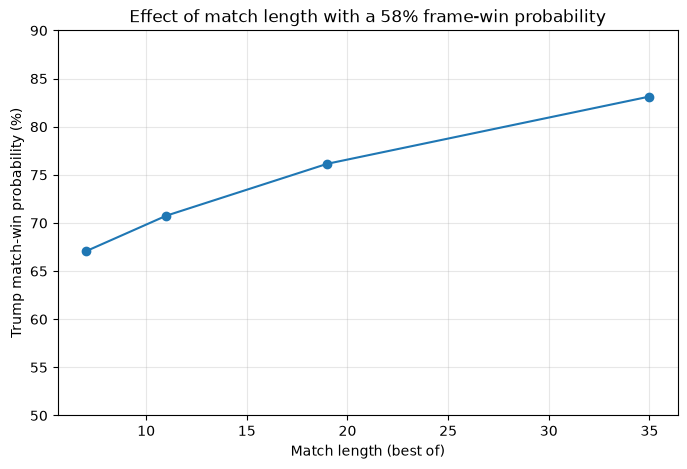

In [13]:
import matplotlib.pyplot as plt

# Plot exact match-win probability against match length.
plt.figure(figsize=(8, 5))
plt.plot(
    comparison["Best of"],
    comparison["Exact"] * 100,
    marker="o"
)

# Label the chart.
plt.xlabel("Match length (best of)")
plt.ylabel("Trump match-win probability (%)")
plt.title("Effect of match length with a 58% frame-win probability")

plt.ylim(50, 90)
plt.grid(alpha=0.3)

plt.show()

The chart makes the effect visually obvious.

With Trump's frame-win probability fixed at 58%, his chance of winning the match rises from about **67% in a best-of-7** to about **83% in a best-of-35**.

The relationship is not caused by any improvement in Trump's per-frame performance. His probability of winning each frame remains exactly the same throughout.

Longer matches simply reduce the influence of short-run variation. Over more frames, the player with the higher underlying frame-win probability is increasingly likely to finish ahead.

This is the core result of the study.

## What if the players are almost evenly matched?

The Trump–Murphy example gives the stronger player a fairly clear frame-level advantage: 58% against 42%.

We can now test whether match length still matters when the difference between the players is much smaller.

Ronnie O'Sullivan and John Higgins provide a useful real-world example. Across their recorded professional head-to-head, they have played 842 frames:

- O'Sullivan has won 429;
- Higgins has won 413.

That gives O'Sullivan a historical frame-win rate of approximately **50.95%**, compared with **49.05%** for Higgins.

They are therefore extremely closely matched at frame level.

For this second model, we will use:

- O'Sullivan: **50.95%** chance of winning each frame;
- Higgins: **49.05%** chance of winning each frame;
- independent frames;
- fixed probabilities throughout the match.

This gives us a useful contrast with Trump–Murphy.

If longer matches favour the better player generally, O'Sullivan's very small frame-level advantage should also become more valuable as the match gets longer — but the effect should be much weaker.

In [15]:
# O'Sullivan's historical frame-win rate against Higgins.
p_osullivan = 0.5095

# Calculate exact match-win probabilities for each format.
osullivan_exact_results = []

for best_of in best_of_values:
    frames_to_win = best_of // 2 + 1

    exact_probability = sum(
        comb(best_of, k)
        * p_osullivan**k
        * (1 - p_osullivan) ** (best_of - k)
        for k in range(frames_to_win, best_of + 1)
    )

    osullivan_exact_results.append(
        (best_of, exact_probability)
    )

osullivan_exact_results

[(7, 0.5207737495935502),
 (11, 0.525701330636696),
 (19, 0.5334412152063456),
 (35, 0.5450724929715244)]

The effect is still present, but it is much smaller.

With O'Sullivan given only a 50.95% chance of winning each frame, his exact match-win probability rises from:

- best of 7 → **52.08%**
- best of 11 → **52.57%**
- best of 19 → **53.34%**
- best of 35 → **54.51%**

So longer matches still favour the slightly stronger player, but only modestly when the underlying frame-level advantage is tiny.

This strengthens the main conclusion.

Match length does not create an advantage by itself. It magnifies whatever underlying frame-level advantage already exists.

When that advantage is substantial, as in the Trump–Murphy example, the effect is large. When the players are almost evenly matched, as in O'Sullivan–Higgins, the effect is much smaller.

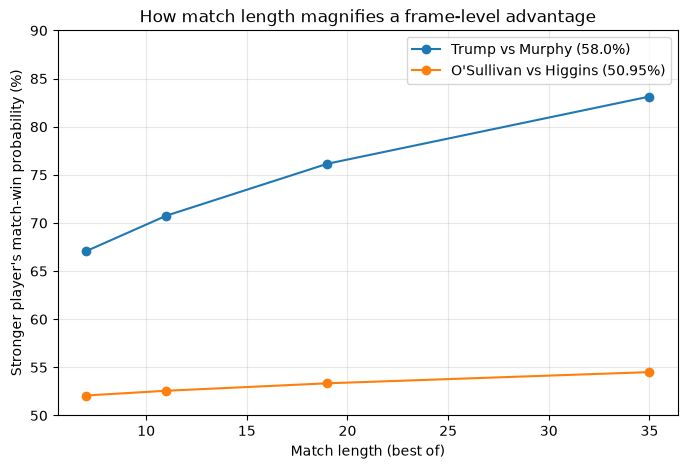

In [16]:
# Extract exact probabilities for the second matchup.
osullivan_probabilities = [
    result[1] for result in osullivan_exact_results
]

# Plot both matchups for comparison.
plt.figure(figsize=(8, 5))

plt.plot(
    best_of_values,
    comparison["Exact"] * 100,
    marker="o",
    label="Trump vs Murphy (58.0%)"
)

plt.plot(
    best_of_values,
    np.array(osullivan_probabilities) * 100,
    marker="o",
    label="O'Sullivan vs Higgins (50.95%)"
)

# Label the chart.
plt.xlabel("Match length (best of)")
plt.ylabel("Stronger player's match-win probability (%)")
plt.title("How match length magnifies a frame-level advantage")

plt.ylim(50, 90)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

The comparison shows that match length does not have the same effect for every matchup.

For Trump–Murphy, the assumed frame-level advantage is substantial: 58% against 42%. As the match length increases, Trump's match-win probability rises sharply.

For O'Sullivan–Higgins, the assumed advantage is tiny: 50.95% against 49.05%. Longer matches still increase O'Sullivan's chance of winning, but only gradually.

This is the more precise version of the usual claim that "longer matches favour the better player."

**Longer matches magnify an existing frame-level advantage. The size of the effect depends on how large that advantage is.**

## Limitations

This is deliberately a simple model.

It assumes that:

* each player's probability of winning a frame is fixed throughout the match;
* every frame is independent;
* the historical head-to-head frame percentages are reasonable illustrative estimates of relative strength;
* match length itself does not change how well either player performs.

Real snooker is more complicated.

Players can move in and out of form during a match. Fatigue, pressure, confidence, playing conditions and the score may affect performance. Historical head-to-head records also combine matches played at different stages of the players' careers and do not necessarily describe their current abilities.

The model therefore does **not** tell us the exact probability that Trump, Murphy, O'Sullivan or Higgins would win a particular real match.

What it isolates is the effect we wanted to study:

**If one player has a fixed advantage in each frame, what does increasing the number of frames do to that advantage?**


## Conclusion

Under this simple model, longer snooker matches do favour the better player.

With Trump given a 58% chance of winning each frame against Murphy, his exact match-win probability rises from about **67% in a best-of-7** to about **83% in a best-of-35**.

The O'Sullivan–Higgins comparison shows why the size of the underlying advantage matters. With only a 50.95% frame-win probability, O'Sullivan's match-win probability rises much more slowly, from about **52% in a best-of-7** to about **55% in a best-of-35**.

The simulation results closely matched the exact binomial calculations, giving us confidence that the simulation behaved as intended.

The important point is not simply that longer matches favour the stronger player.

**Longer matches magnify whatever frame-level advantage already exists. The larger that underlying advantage, the more consequential match length becomes.**
